# Code for K-Shape

In [ ]:
!pip3 install git+https://github.com/NetManAIOps/sktime.git sklearn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sktime.clustering.k_shapes import TimeSeriesKShapes

/var/folders/4h/42h1mfc50gz95cz12q77s1_80000gn/T/ipykernel_76537/1527226579.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


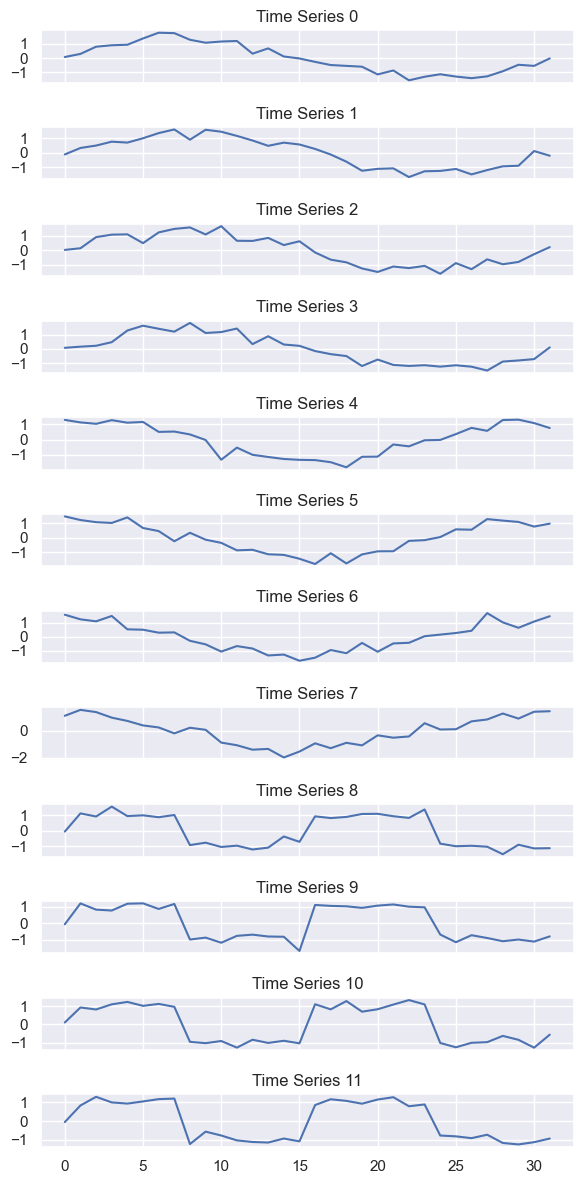

In [2]:
# Generate 3 clearly separated shape clusters
rng = np.random.default_rng(0)
n_clusters = 3
n_per_cluster = 4
sz = 32
t = np.linspace(0, 2 * np.pi, sz)

prototype_0 = np.sin(t)
prototype_1 = np.sin(t + np.pi / 2)
prototype_2 = np.sign(np.sin(2 * t))
prototypes = np.vstack([prototype_0, prototype_1, prototype_2])

X_parts = []
for c in range(n_clusters):
    noise = rng.normal(loc=0.0, scale=0.20, size=(n_per_cluster, sz))
    X_parts.append(prototypes[c] + noise)
X = np.vstack(X_parts)

# Scale each series to mean=0 and std=1
series_mean = X.mean(axis=1, keepdims=True)
series_std = X.std(axis=1, keepdims=True)
series_std[series_std == 0] = 1.0
X = (X - series_mean) / series_std

sns.set()
fig, ax = plt.subplots(X.shape[0], 1, figsize=(6, X.shape[0]), sharex=True)
for i in range(X.shape[0]):
    ax[i].plot(X[i])
    ax[i].set_title(f'Time Series {i}')
fig.tight_layout()
fig.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Predicted class labels: [0 0 0 0 1 1 1 1 2 2 2 2]


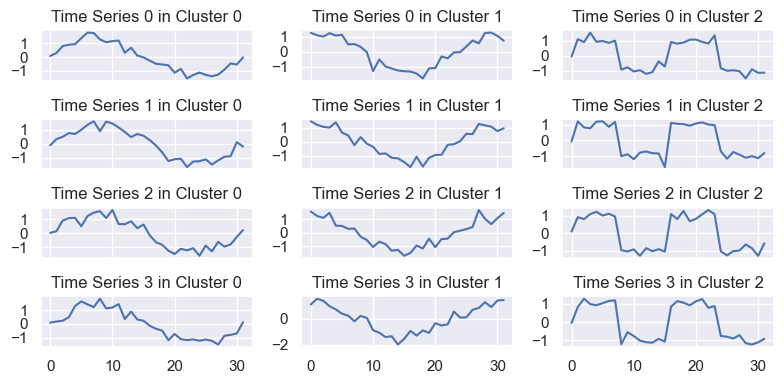

In [3]:
# Group by KShape (sktime)
ks = TimeSeriesKShapes(n_clusters=3, n_init=10, verbose=False, random_state=0)

# Fit and get cluster labels
y_pred = ks.fit_predict(X.reshape(X.shape[0], X.shape[1], 1))
print("Predicted class labels:", y_pred)

# Plot each cluster safely (including possible empty clusters)
cluster_counts = np.bincount(y_pred, minlength=ks.n_clusters)
n_rows = int(cluster_counts.max())
fig, ax = plt.subplots(n_rows, ks.n_clusters, figsize=(8, n_rows), sharex=True, squeeze=False)
for i in range(ks.n_clusters):
    cluster_series = X[y_pred == i]
    for j in range(n_rows):
        if j < cluster_series.shape[0]:
            ax[j, i].plot(cluster_series[j])
            ax[j, i].set_title(f'Time Series {j} in Cluster {i}')
        else:
            ax[j, i].axis('off')
fig.tight_layout()